# Air Passenger Demand Forecasting — End-to-End Data Science Project

**Goal:** Forecast monthly airline passenger demand using statistical time-series models, robust validation, residual diagnostics, prediction intervals, and business insights.

**Models:** Naive, Seasonal Naive, ARIMA, SARIMA, Holt-Winters  
**Evaluation:** MAE, RMSE, MAPE, rolling-origin validation, Ljung-Box diagnostics, 95% prediction intervals

In [1]:
# 1. Imports
import warnings
warnings.filterwarnings("ignore")

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

## 2. Business Problem

The objective is to forecast monthly airline passenger demand using historical passenger data.

Accurate demand forecasts can support capacity planning, workforce scheduling, resource allocation, and seasonal operational planning.

In [7]:
# 3. Load data
df = pd.read_csv('airline_passengers.csv')

df.head()

,Month,Thousands of Passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [8]:
# 4. Data validation and preprocessing
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

df["Month"] = pd.to_datetime(df["Month"], format="%Y-%m", errors="coerce")
df["Thousands of Passengers"] = pd.to_numeric(
    df["Thousands of Passengers"], errors="coerce"
)

df = df.dropna().sort_values("Month")
df = df.drop_duplicates(subset="Month")
df = df.set_index("Month").asfreq("MS")

df["Thousands of Passengers"] = df["Thousands of Passengers"].interpolate()

df = df.rename(columns={"Thousands of Passengers": "Passengers"})
y = df["Passengers"]

print("\nDate range:", y.index.min(), "to", y.index.max())
print("Observations:", len(y))
display(df.head())

Shape: (145, 2)

Data types:


Month                       object
Thousands of Passengers    float64
dtype: object


Missing values:


Month                      0
Thousands of Passengers    1
dtype: int64


Duplicate rows: 0

Date range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00
Observations: 144


,Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0


,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


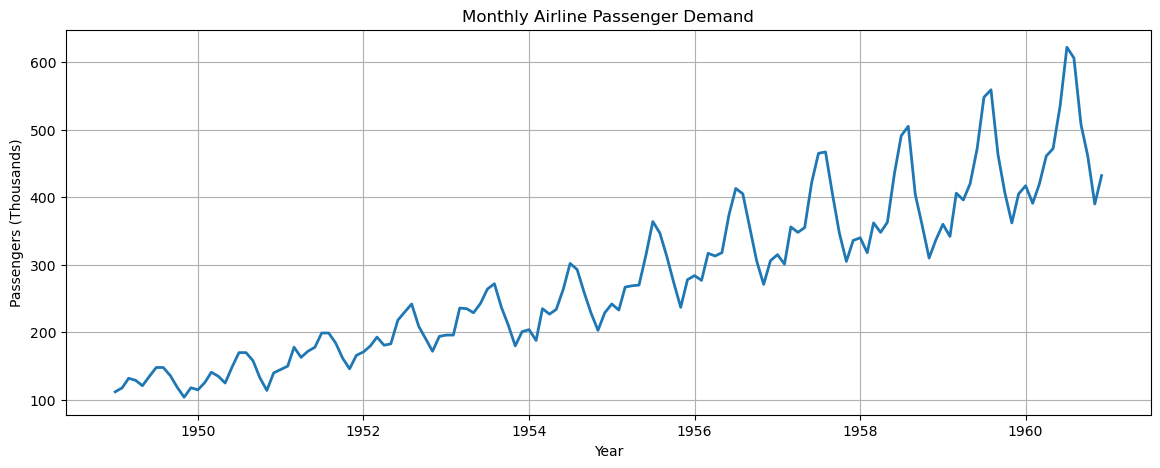

In [9]:
# 5. Exploratory data analysis
display(df.describe())

plt.figure(figsize=(14, 5))
plt.plot(y, linewidth=2)
plt.title("Monthly Airline Passenger Demand")
plt.xlabel("Year")
plt.ylabel("Passengers (Thousands)")
plt.show()

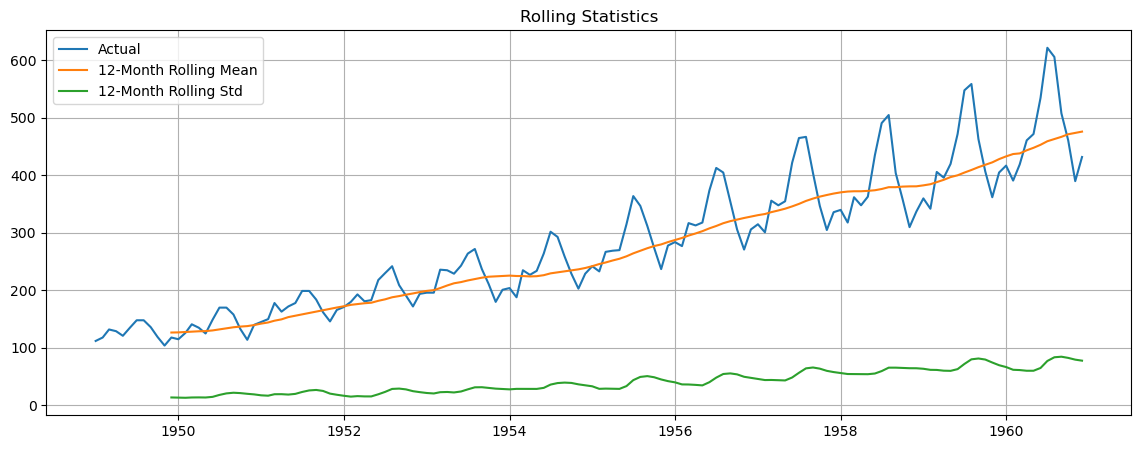

In [10]:
# 6. Rolling statistics
rolling_mean = y.rolling(12).mean()
rolling_std = y.rolling(12).std()

plt.figure(figsize=(14, 5))
plt.plot(y, label="Actual")
plt.plot(rolling_mean, label="12-Month Rolling Mean")
plt.plot(rolling_std, label="12-Month Rolling Std")
plt.title("Rolling Statistics")
plt.legend()
plt.show()


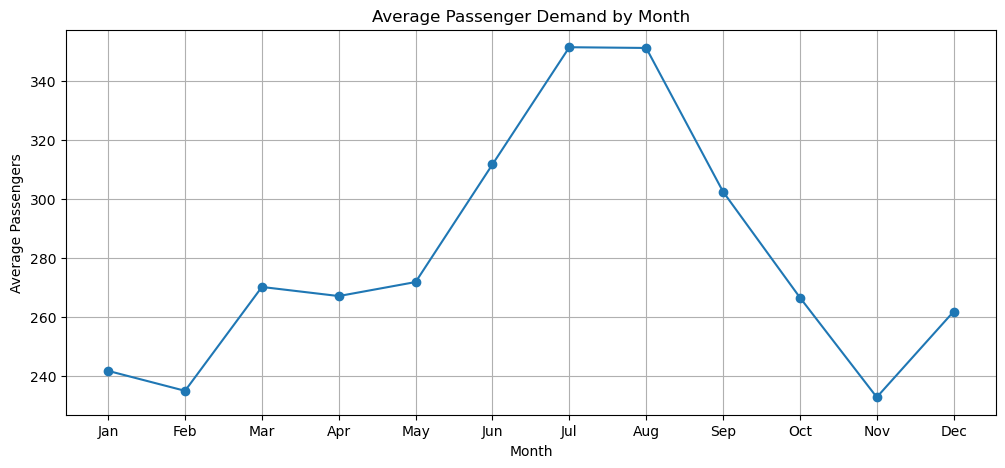

In [11]:
# 7. Monthly seasonality
monthly_avg = y.groupby(y.index.month).mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(12, 5))
plt.plot(month_names, monthly_avg.values, marker="o")
plt.title("Average Passenger Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Passengers")
plt.show()


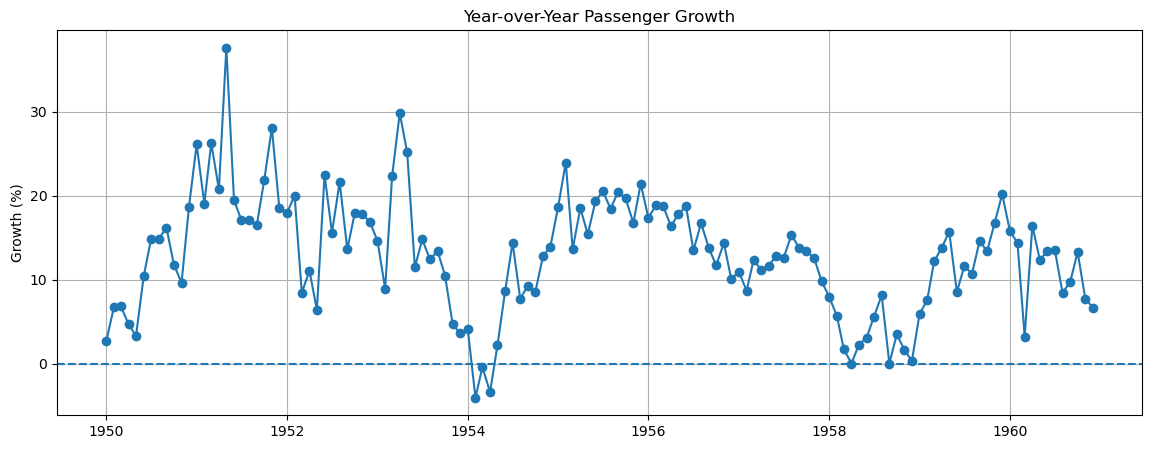

In [12]:
# 8. Year-over-year growth
yoy_growth = y.pct_change(12) * 100

plt.figure(figsize=(14, 5))
plt.plot(yoy_growth, marker="o")
plt.axhline(0, linestyle="--")
plt.title("Year-over-Year Passenger Growth")
plt.ylabel("Growth (%)")
plt.show()

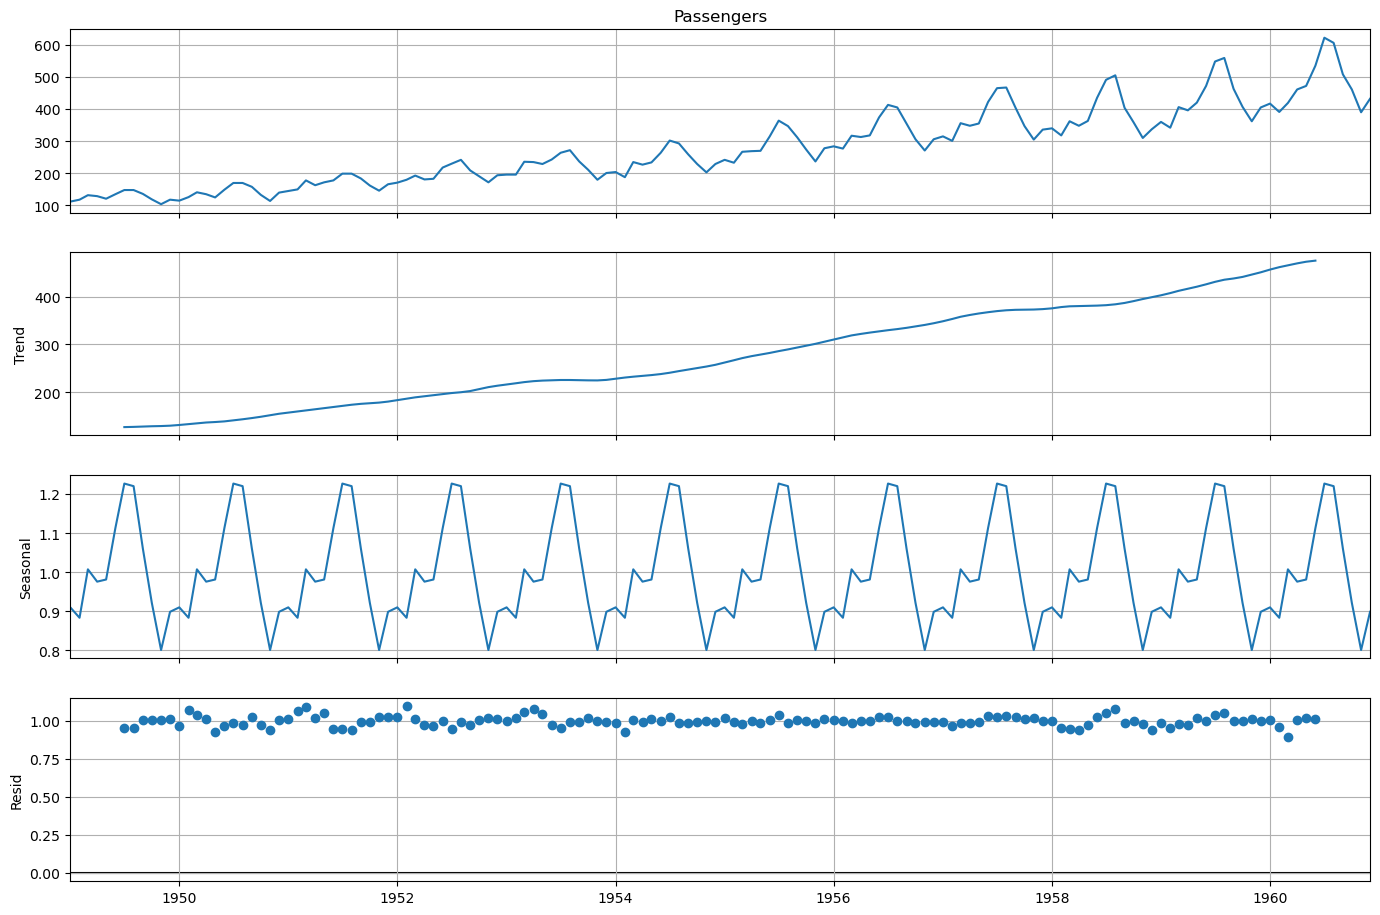

In [13]:
# 9. Seasonal decomposition
decomposition = seasonal_decompose(y, model="multiplicative", period=12)
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

In [14]:
# 10. Stationarity
def adf_test(series, name="Series"):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"--- {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.6f}")
    print("Conclusion:", "Stationary" if result[1] < 0.05 else "Non-stationary")
    print()

adf_test(y, "Original Series")
adf_test(y.diff(), "First Difference")
adf_test(y.diff(12), "Seasonal Difference (12 months)")

--- Original Series ---
ADF Statistic: 0.8154
p-value: 0.991880
Conclusion: Non-stationary

--- First Difference ---
ADF Statistic: -2.8293
p-value: 0.054213
Conclusion: Non-stationary

--- Seasonal Difference (12 months) ---
ADF Statistic: -3.3830
p-value: 0.011551
Conclusion: Stationary



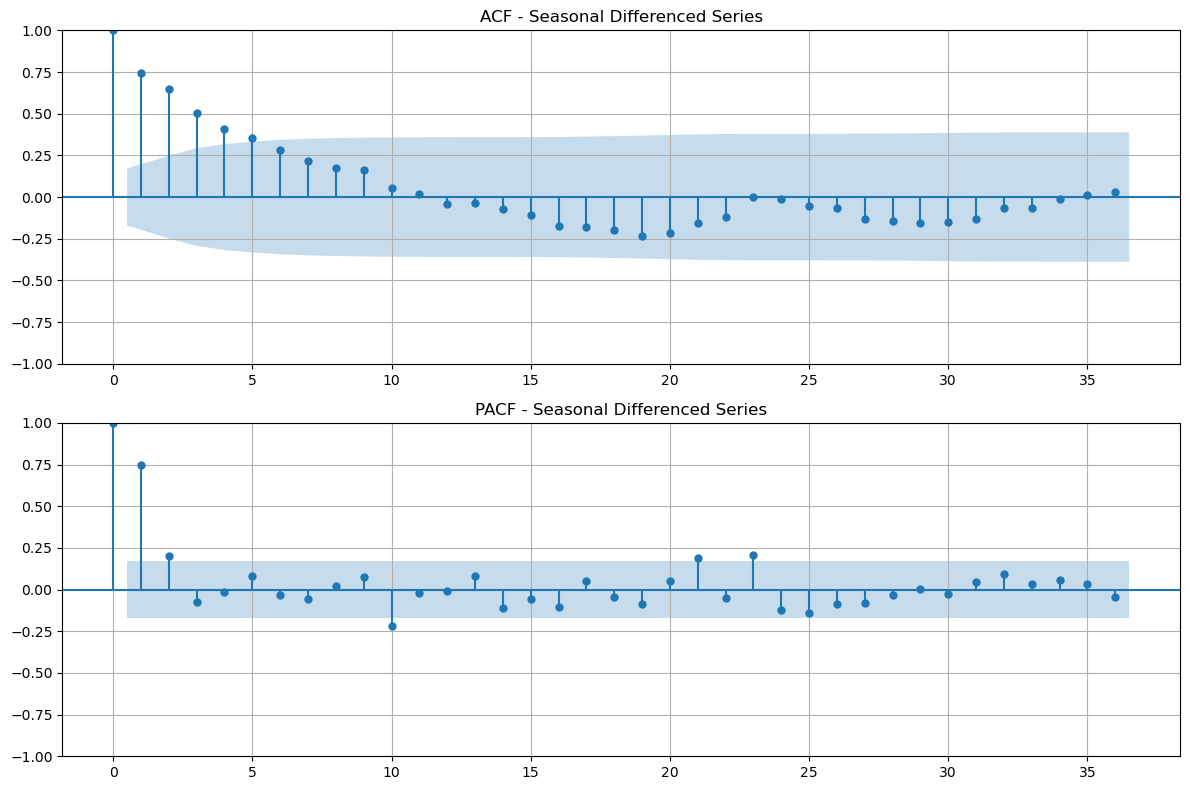

In [15]:
# 11. ACF / PACF
stationary_series = y.diff(12).dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(stationary_series, lags=36, ax=axes[0])
axes[0].set_title("ACF - Seasonal Differenced Series")

plot_pacf(stationary_series, lags=36, ax=axes[1], method="ywm")
axes[1].set_title("PACF - Seasonal Differenced Series")

plt.tight_layout()
plt.show()

Train: 1949-01-01 00:00:00 to 1958-12-01 00:00:00
Test : 1959-01-01 00:00:00 to 1960-12-01 00:00:00


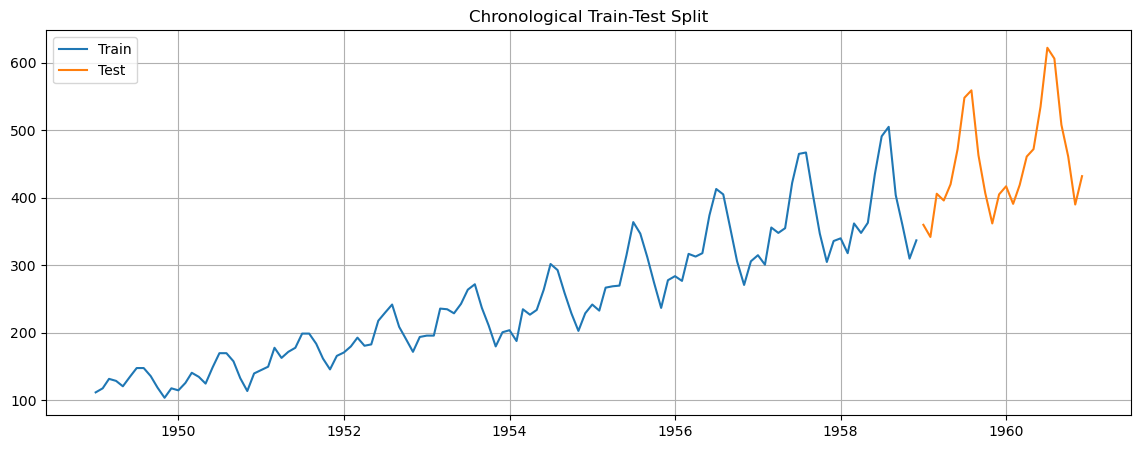

In [16]:
# 12. Chronological train/test split
test_size = 24
train = y.iloc[:-test_size]
test = y.iloc[-test_size:]

print("Train:", train.index.min(), "to", train.index.max())
print("Test :", test.index.min(), "to", test.index.max())

plt.figure(figsize=(14, 5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.title("Chronological Train-Test Split")
plt.legend()
plt.show()

In [17]:
# 13. Evaluation function
def evaluate_forecast(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "MAPE (%)": mean_absolute_percentage_error(actual, predicted) * 100
    }

In [18]:
# 14. Naive and Seasonal Naive baselines
naive_forecast = pd.Series(train.iloc[-1], index=test.index)

seasonal_naive_forecast = pd.Series(
    [train.iloc[-12 + (i % 12)] for i in range(len(test))],
    index=test.index
)

naive_metrics = evaluate_forecast(test, naive_forecast)
seasonal_naive_metrics = evaluate_forecast(test, seasonal_naive_forecast)

print("Naive:", naive_metrics)
print("Seasonal Naive:", seasonal_naive_metrics)

Naive: {'MAE': 115.25, 'RMSE': np.float64(137.32898455897794), 'MAPE (%)': 23.577467413678153}
Seasonal Naive: {'MAE': 71.25, 'RMSE': np.float64(76.99458855443457), 'MAPE (%)': 15.523355162420376}


In [19]:
# 15. Automated ARIMA selection using AIC
p_values = range(0, 4)
d_values = range(0, 3)
q_values = range(0, 4)

arima_results = []

for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        fitted = ARIMA(train, order=(p, d, q)).fit()
        arima_results.append({
            "order": (p, d, q),
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })
    except Exception:
        pass

arima_results_df = pd.DataFrame(arima_results).sort_values("AIC").reset_index(drop=True)
display(arima_results_df.head(10))

best_arima_order = tuple(arima_results_df.iloc[0]["order"])
print("Best ARIMA order:", best_arima_order)


C:\Users\deepe\anaconda3\Ananconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,AIC,BIC
0,"(3, 1, 3)",1089.755699,1109.209564
1,"(2, 1, 2)",1093.068907,1106.964525
2,"(3, 2, 3)",1101.744590,1121.139382
3,"(3, 0, 3)",1107.325814,1129.625748
4,"(3, 1, 2)",1112.575325,1129.250066
5,"(2, 1, 1)",1113.046819,1124.163313
6,"(3, 1, 1)",1114.435888,1128.331505
7,"(1, 1, 2)",1118.099482,1129.215976
8,"(2, 1, 3)",1119.015408,1135.690149
9,"(1, 1, 3)",1119.789954,1133.685571


Best ARIMA order: (3, 1, 3)


In [20]:
# 16. Best ARIMA forecast
arima_fit = ARIMA(train, order=best_arima_order).fit()
arima_forecast = arima_fit.forecast(len(test))
arima_forecast.index = test.index

arima_metrics = evaluate_forecast(test, arima_forecast)
print(arima_metrics)

{'MAE': 64.01218719452116, 'RMSE': np.float64(88.16036031847909), 'MAPE (%)': 12.563389317332577}


C:\Users\deepe\anaconda3\Ananconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [21]:
# 17. Automated SARIMA selection using AIC
p_values = range(0, 3)
d_values = range(0, 2)
q_values = range(0, 3)
P_values = range(0, 3)
D_values = range(0, 2)
Q_values = range(0, 3)
seasonal_period = 12

sarima_results = []

for order in itertools.product(p_values, d_values, q_values):
    for seasonal_tuple in itertools.product(P_values, D_values, Q_values):
        seasonal_order = (
            seasonal_tuple[0],
            seasonal_tuple[1],
            seasonal_tuple[2],
            seasonal_period
        )
        try:
            fitted = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)

            sarima_results.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": fitted.aic,
                "BIC": fitted.bic
            })
        except Exception:
            pass

sarima_results_df = pd.DataFrame(sarima_results).sort_values("AIC").reset_index(drop=True)
display(sarima_results_df.head(10))

best_sarima_order = tuple(sarima_results_df.iloc[0]["order"])
best_sarima_seasonal = tuple(sarima_results_df.iloc[0]["seasonal_order"])

print("Best SARIMA order:", best_sarima_order)
print("Best seasonal order:", best_sarima_seasonal)

C:\Users\deepe\anaconda3\Ananconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\deepe\anaconda3\Ananconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\deepe\anaconda3\Ananconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\deepe\anaconda3\Ananconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\deepe\anaconda3\Ananconda\Lib\site-packages\statsmo

,order,seasonal_order,AIC,BIC
0,"(0, 1, 2)","(1, 1, 2, 12)",612.538173,626.830333
1,"(1, 1, 2)","(1, 1, 2, 12)",614.222634,630.896820
2,"(0, 1, 2)","(2, 1, 2, 12)",615.576673,632.250860
3,"(0, 1, 1)","(1, 1, 2, 12)",617.289380,629.261625
4,"(1, 1, 2)","(2, 1, 2, 12)",617.290329,636.346542
5,"(2, 1, 2)","(1, 1, 2, 12)",617.339323,636.395536
6,"(1, 1, 2)","(0, 1, 2, 12)",617.727769,632.019929
7,"(1, 1, 1)","(1, 1, 2, 12)",618.392824,632.759518
8,"(2, 1, 2)","(0, 1, 2, 12)",618.444372,635.118559
9,"(1, 0, 2)","(1, 1, 2, 12)",618.548863,635.310007


Best SARIMA order: (0, 1, 2)
Best seasonal order: (1, 1, 2, 12)


In [22]:
# 18. Best SARIMA forecast
sarima_fit = SARIMAX(
    train,
    order=best_sarima_order,
    seasonal_order=best_sarima_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_forecast = sarima_fit.get_forecast(len(test)).predicted_mean
sarima_forecast.index = test.index

sarima_metrics = evaluate_forecast(test, sarima_forecast)
print(sarima_metrics)


{'MAE': 47.17925133579513, 'RMSE': np.float64(51.50022742322421), 'MAPE (%)': 10.530757412824503}


In [23]:
# 19. Holt-Winters models
hw_additive = ExponentialSmoothing(
    train, trend="add", seasonal="add",
    seasonal_periods=12, initialization_method="estimated"
).fit()

hw_multiplicative = ExponentialSmoothing(
    train, trend="add", seasonal="mul",
    seasonal_periods=12, initialization_method="estimated"
).fit()

hw_additive_forecast = hw_additive.forecast(len(test))
hw_multiplicative_forecast = hw_multiplicative.forecast(len(test))

hw_additive_forecast.index = test.index
hw_multiplicative_forecast.index = test.index

hw_additive_metrics = evaluate_forecast(test, hw_additive_forecast)
hw_multiplicative_metrics = evaluate_forecast(test, hw_multiplicative_forecast)

print("Holt-Winters Additive:", hw_additive_metrics)
print("Holt-Winters Multiplicative:", hw_multiplicative_metrics)

Holt-Winters Additive: {'MAE': 31.079801940231395, 'RMSE': np.float64(35.76233992722469), 'MAPE (%)': 6.6371328318383425}
Holt-Winters Multiplicative: {'MAE': 28.977187800132373, 'RMSE': np.float64(32.488600501490225), 'MAPE (%)': 6.391020460830949}


In [24]:
# 20. Holdout model comparison
results = pd.DataFrame({
    "Naive": naive_metrics,
    "Seasonal Naive": seasonal_naive_metrics,
    "ARIMA": arima_metrics,
    "SARIMA": sarima_metrics,
    "Holt-Winters Additive": hw_additive_metrics,
    "Holt-Winters Multiplicative": hw_multiplicative_metrics
}).T.sort_values("RMSE")

display(results)

,MAE,RMSE,MAPE (%)
Holt-Winters Multiplicative,28.977188,32.488601,6.391020
Holt-Winters Additive,31.079802,35.762340,6.637133
SARIMA,47.179251,51.500227,10.530757
Seasonal Naive,71.250000,76.994589,15.523355
ARIMA,64.012187,88.160360,12.563389
Naive,115.250000,137.328985,23.577467


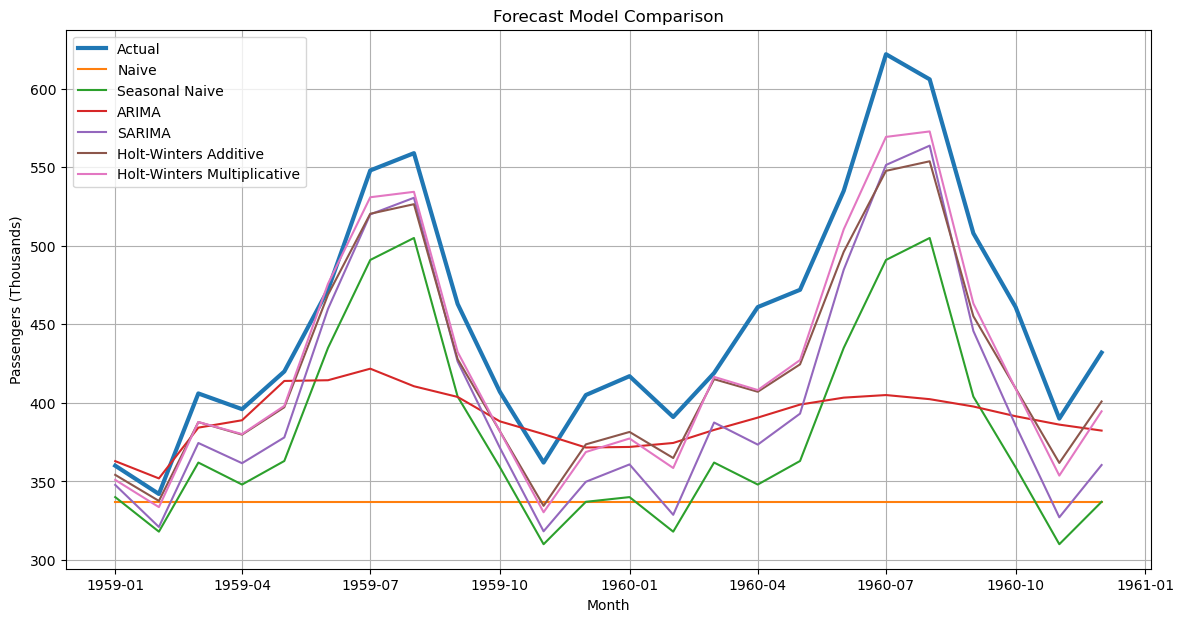

In [25]:
# 21. Forecast comparison plot
plt.figure(figsize=(14, 7))
plt.plot(test, label="Actual", linewidth=3)
plt.plot(naive_forecast, label="Naive")
plt.plot(seasonal_naive_forecast, label="Seasonal Naive")
plt.plot(arima_forecast, label="ARIMA")
plt.plot(sarima_forecast, label="SARIMA")
plt.plot(hw_additive_forecast, label="Holt-Winters Additive")
plt.plot(hw_multiplicative_forecast, label="Holt-Winters Multiplicative")
plt.title("Forecast Model Comparison")
plt.xlabel("Month")
plt.ylabel("Passengers (Thousands)")
plt.legend()
plt.show()

In [26]:
# 22. Rolling-origin cross-validation
def rolling_origin_cv(series, model_type, model_params,
                      initial_train_size, horizon=12, step=12):
    errors = []

    for end in range(initial_train_size, len(series) - horizon + 1, step):
        train_fold = series.iloc[:end]
        test_fold = series.iloc[end:end + horizon]

        if model_type == "ARIMA":
            fitted = ARIMA(train_fold, order=model_params).fit()
            forecast = fitted.forecast(horizon)

        elif model_type == "SARIMA":
            order, seasonal_order = model_params
            fitted = SARIMAX(
                train_fold,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)
            forecast = fitted.forecast(horizon)

        elif model_type == "Holt-Winters":
            trend, seasonal = model_params
            fitted = ExponentialSmoothing(
                train_fold,
                trend=trend,
                seasonal=seasonal,
                seasonal_periods=12,
                initialization_method="estimated"
            ).fit()
            forecast = fitted.forecast(horizon)

        errors.append(evaluate_forecast(test_fold, forecast))

    return pd.DataFrame(errors)

In [38]:
# 23. Rolling-origin validation for all major model families
arima_cv=rolling_origin_cv(y,"ARIMA",best_arima_order,72,12,12)
sarima_cv=rolling_origin_cv(y,"SARIMA",(best_sarima_order,best_sarima_seasonal),72,12,12)
hw_additive_cv=rolling_origin_cv(y,"Holt-Winters",("add","add"),72,12,12)
hw_multiplicative_cv=rolling_origin_cv(y,"Holt-Winters",("add","mul"),72,12,12)
cv_summary=pd.DataFrame({"ARIMA":arima_cv.mean(),"SARIMA":sarima_cv.mean(),"Holt-Winters Additive":hw_additive_cv.mean(),"Holt-Winters Multiplicative":hw_multiplicative_cv.mean()}).T.sort_values("RMSE")
display(cv_summary)

C:\Users\deepe\anaconda3\Ananconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\deepe\anaconda3\Ananconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\deepe\anaconda3\Ananconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\deepe\anaconda3\Ananconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\deepe\anaconda3\Ananconda\Lib\site-packages\statsmo

,MAE,RMSE,MAPE (%)
Holt-Winters Multiplicative,15.013891,18.556259,4.028123
SARIMA,18.796110,22.747210,4.877830
Holt-Winters Additive,19.887154,24.482699,5.355248
ARIMA,37.181764,48.771588,9.200470


In [39]:
# 24. Final model selection
# Primary selection criterion: unseen holdout RMSE.
# Rolling-origin CV above is a robustness check.
final_model_name=results["RMSE"].idxmin()
print("Selected final model:",final_model_name)
print("Holdout RMSE:",round(results.loc[final_model_name,"RMSE"],2))
print("Holdout MAPE:",round(results.loc[final_model_name,"MAPE (%)"],2),"%")

Selected final model: Holt-Winters Multiplicative
Holdout RMSE: 32.49
Holdout MAPE: 6.39 %


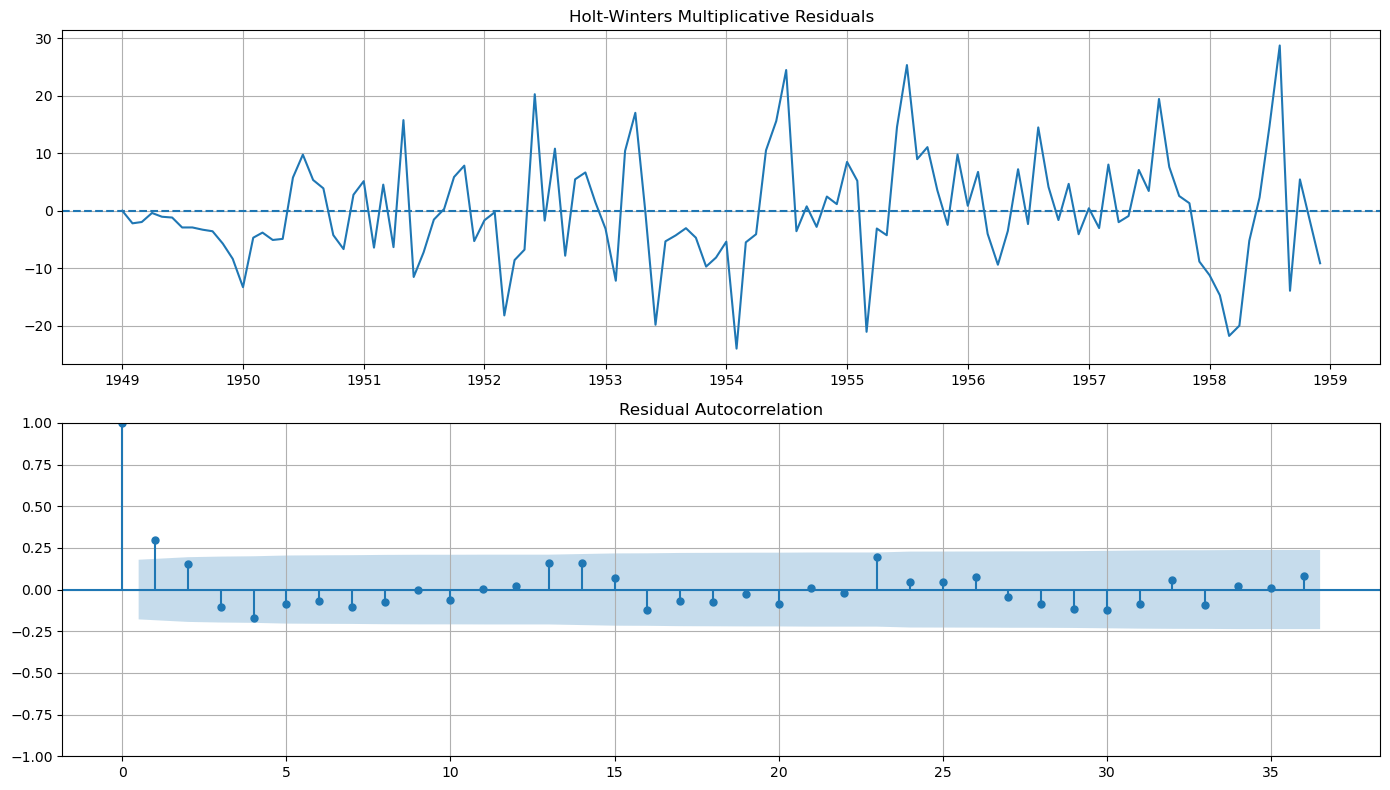

In [40]:
# 25. Final-model residual diagnostics
final_hw_fit=ExponentialSmoothing(train,trend="add",seasonal="mul",seasonal_periods=12,initialization_method="estimated").fit()
final_residuals=train-final_hw_fit.fittedvalues
fig,axes=plt.subplots(2,1,figsize=(14,8))
axes[0].plot(final_residuals); axes[0].axhline(0,linestyle="--"); axes[0].set_title("Holt-Winters Multiplicative Residuals")
plot_acf(final_residuals.dropna(),lags=36,ax=axes[1]); axes[1].set_title("Residual Autocorrelation")
plt.tight_layout(); plt.show()

In [41]:
# 26. Ljung-Box test on final-model residuals
ljung_box=acorr_ljungbox(final_residuals.dropna(),lags=[12,24],return_df=True)
display(ljung_box)
print("Inspect the p-values before making a definitive claim about remaining autocorrelation.")

,lb_stat,lb_pvalue
12,23.039850,0.02739
24,41.276548,0.01553


Inspect the p-values before making a definitive claim about remaining autocorrelation.


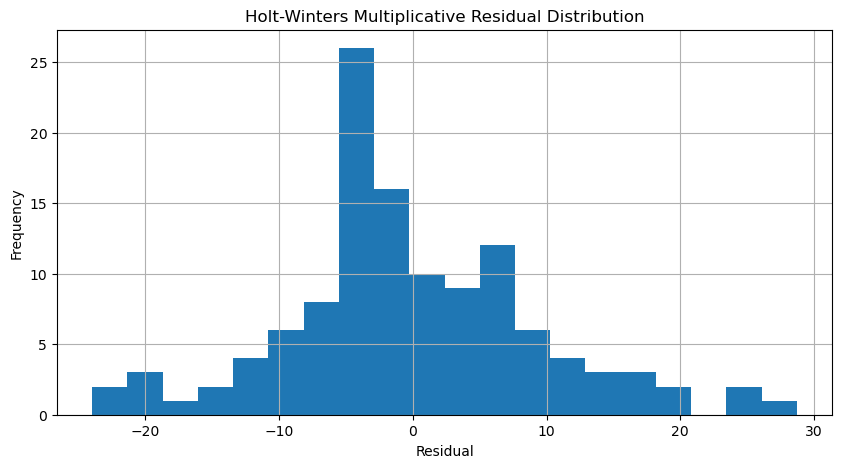

In [42]:
# 27. Final-model residual distribution
plt.figure(figsize=(10,5)); plt.hist(final_residuals.dropna(),bins=20); plt.title("Holt-Winters Multiplicative Residual Distribution"); plt.xlabel("Residual"); plt.ylabel("Frequency"); plt.show()

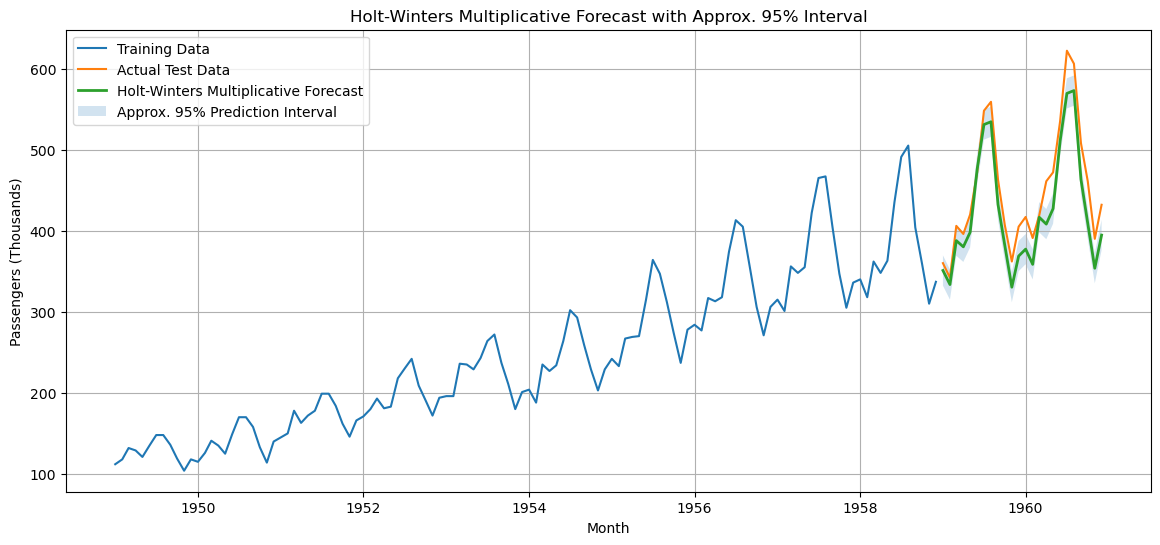

In [43]:
# 28. Holdout forecast with approximate 95% prediction interval
hw_holdout_forecast=hw_multiplicative_forecast
resid_std=final_hw_fit.resid.std(ddof=1)
lower_95=hw_holdout_forecast-1.96*resid_std
upper_95=hw_holdout_forecast+1.96*resid_std
plt.figure(figsize=(14,6)); plt.plot(train,label="Training Data"); plt.plot(test,label="Actual Test Data"); plt.plot(hw_holdout_forecast,label="Holt-Winters Multiplicative Forecast",linewidth=2)
plt.fill_between(test.index,lower_95,upper_95,alpha=.2,label="Approx. 95% Prediction Interval")
plt.title("Holt-Winters Multiplicative Forecast with Approx. 95% Interval"); plt.xlabel("Month"); plt.ylabel("Passengers (Thousands)"); plt.legend(); plt.show()

In [44]:
# 29. Refit selected final model on all historical data
final_model=ExponentialSmoothing(y,trend="add",seasonal="mul",seasonal_periods=12,initialization_method="estimated").fit()

In [45]:
# 30. Future 12-month forecast
future_steps=12
future_forecast=final_model.forecast(future_steps)
full_residuals=y-final_model.fittedvalues
full_resid_std=full_residuals.std(ddof=1)
future_lower_95=future_forecast-1.96*full_resid_std
future_upper_95=future_forecast+1.96*full_resid_std
forecast_table=pd.DataFrame({"Forecast":future_forecast,"Lower_95_Approx":future_lower_95,"Upper_95_Approx":future_upper_95})
display(forecast_table)

,Forecast,Lower_95_Approx,Upper_95_Approx
1961-01-01,445.242402,424.540691,465.944113
1961-02-01,418.225352,397.523640,438.927063
1961-03-01,465.309707,444.607995,486.011418
1961-04-01,494.951212,474.249501,515.652923
1961-05-01,505.475849,484.774138,526.177560
1961-06-01,573.312582,552.610871,594.014293
1961-07-01,663.596287,642.894576,684.297998
1961-08-01,654.903933,634.202222,675.605644
1961-09-01,546.760954,526.059242,567.462665
1961-10-01,488.446890,467.745178,509.148601


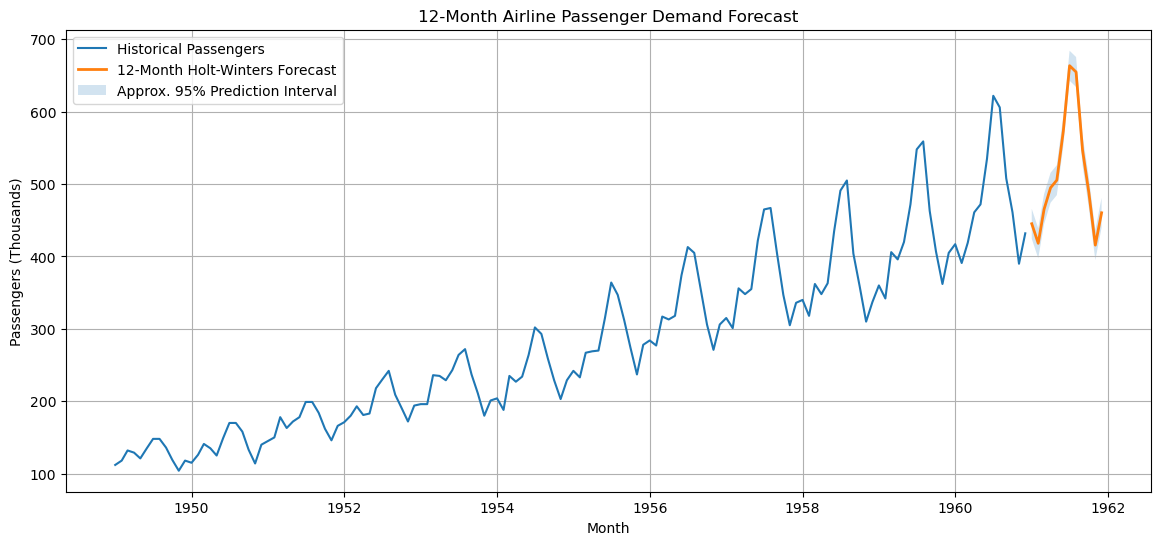

In [46]:
# 31. Future  visualization
plt.figure(figsize=(14,6)); plt.plot(y,label="Historical Passengers"); plt.plot(future_forecast,label="12-Month Holt-Winters Forecast",linewidth=2)
plt.fill_between(future_forecast.index,future_lower_95,future_upper_95,alpha=.2,label="Approx. 95% Prediction Interval")
plt.title("12-Month Airline Passenger Demand Forecast"); plt.xlabel("Month"); plt.ylabel("Passengers (Thousands)"); plt.legend(); plt.show()

In [47]:
# 32.  insights
peak_month=future_forecast.idxmax(); peak_value=future_forecast.max(); lowest_month=future_forecast.idxmin(); lowest_value=future_forecast.min()
average_forecast=future_forecast.mean(); historical_average=y.mean(); forecast_growth=(average_forecast/historical_average-1)*100
print("Selected final model: Holt-Winters Multiplicative")
print(f"Peak forecast month: {peak_month.strftime('%B %Y')}"); print(f"Peak forecasted passengers: {peak_value:.2f} thousand")
print(f"\nLowest forecast month: {lowest_month.strftime('%B %Y')}"); print(f"Lowest forecasted passengers: {lowest_value:.2f} thousand")
print(f"\nAverage forecasted passengers: {average_forecast:.2f} thousand"); print(f"Average forecast vs historical average: {forecast_growth:.2f}%")

Selected final model: Holt-Winters Multiplicative
Peak forecast month: July 1961
Peak forecasted passengers: 663.60 thousand

Lowest forecast month: November 1961
Lowest forecasted passengers: 415.72 thousand

Average forecasted passengers: 511.03 thousand
Average forecast vs historical average: 82.32%


In [48]:
# 33. Final model comparison
final_comparison=results.copy(); final_comparison["Rank"]=final_comparison["RMSE"].rank(method="min").astype(int); final_comparison=final_comparison.sort_values("Rank"); display(final_comparison)
print("\nFinal selected model based on holdout RMSE:",final_model_name)

,MAE,RMSE,MAPE (%),Rank
Holt-Winters Multiplicative,28.977188,32.488601,6.391020,1
Holt-Winters Additive,31.079802,35.762340,6.637133,2
SARIMA,47.179251,51.500227,10.530757,3
Seasonal Naive,71.250000,76.994589,15.523355,4
ARIMA,64.012187,88.160360,12.563389,5
Naive,115.250000,137.328985,23.577467,6



Final selected model based on holdout RMSE: Holt-Winters Multiplicative


# Conclusion

This project developed an end-to-end monthly airline passenger demand forecasting pipeline. The analysis examined trend and seasonality, stationarity, ACF/PACF patterns, and multiple forecasting approaches using out-of-sample metrics.

Naive, Seasonal Naive, ARIMA, SARIMA, and Holt-Winters models were evaluated using MAE, RMSE, and MAPE. On the held-out test period, **Holt-Winters Multiplicative performed best**, with an RMSE of approximately **32.49** and MAPE of approximately **6.39%**.

Rolling-origin validation was added as a robustness check across multiple historical forecast windows. Residual diagnostics and the Ljung-Box test were used to assess remaining temporal dependence.

Because Holt-Winters Multiplicative was the best-performing model on the unseen holdout period, it was selected as the final forecasting model and refitted on the complete historical dataset. It was then used to generate a **12-month passenger-demand forecast** with an **approximate 95% prediction interval based on residual uncertainty**.

The forecast can support capacity planning, workforce scheduling, resource allocation, and preparation for seasonal peaks and troughs.